In [65]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt


In [66]:

stocks = ["JPM","^MXX","PLTR","V"]
prices = yf.download(stocks,start='2020-01-01',end='2026-01-01',progress=False)["Close"]
returns = prices.pct_change().dropna()

mean_returns = returns.mean()
cov_matrix = returns.cov()

print("Media diaria retornos:")
print(mean_returns)
print("\\nMatriz de covarianza:")
print(cov_matrix)

Media diaria retornos:
Ticker
JPM     0.001113
PLTR    0.003100
V       0.000542
^MXX    0.000444
dtype: float64
\nMatriz de covarianza:
Ticker       JPM      PLTR         V      ^MXX
Ticker                                        
JPM     0.000243  0.000180  0.000109  0.000047
PLTR    0.000180  0.001933  0.000158  0.000089
V       0.000109  0.000158  0.000201  0.000038
^MXX    0.000047  0.000089  0.000038  0.000092


C:\Users\marce\AppData\Local\Temp\ipykernel_15040\177806386.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(stocks,start='2020-01-01',end='2026-01-01',progress=False)["Close"]
C:\Users\marce\AppData\Local\Temp\ipykernel_15040\177806386.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna()


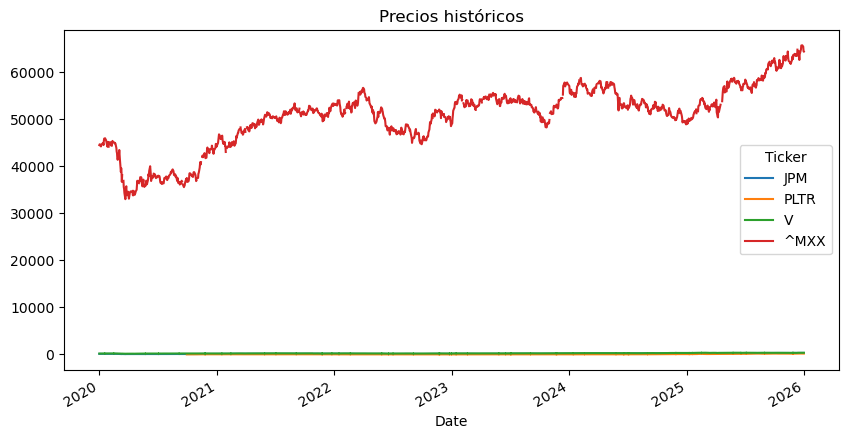

In [67]:
prices.plot(figsize=(10,5),title="Precios históricos")
plt.show()

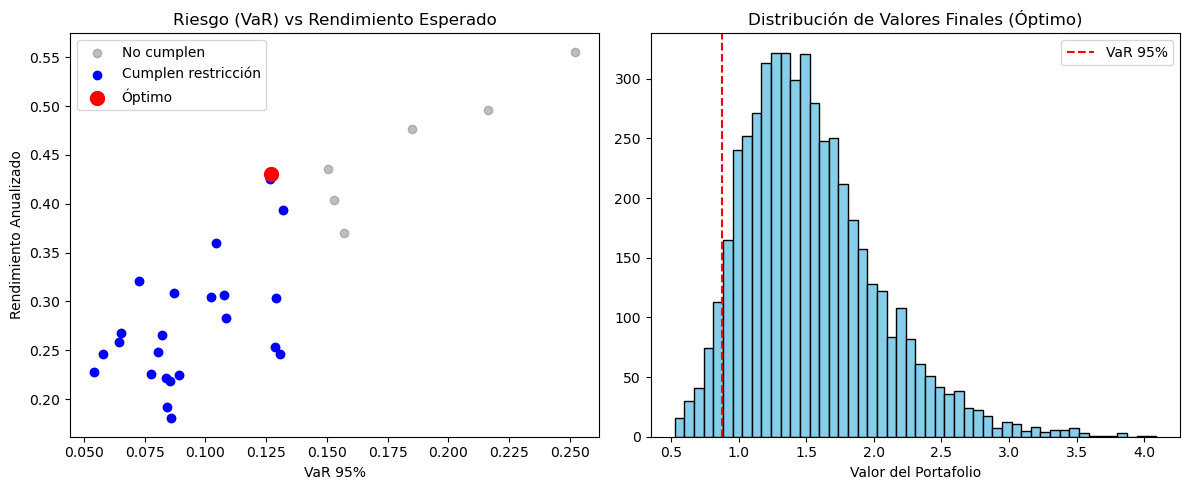

--- RESULTADOS ---
1. Portafolios que cumplen la restricción: 24 de 30
2. Rendimiento esperado del óptimo: 43.01%
3. Rendimiento sacrificado por controlar riesgo: 12.57%


In [71]:

k = len(stocks)
num_sim = 5000
n_combinations = 30 
limite_var = 0.15
mean_returns = returns.mean()
cov_matrix = returns.cov()
L = np.linalg.cholesky(cov_matrix)

results = []

# 2. Bucle de Portafolios Aleatorios
for i in range(n_combinations):
    weights = np.random.rand(k)
    weights /= np.sum(weights)
    
    # Simulación MGB simplificada para velocidad
    # Rendimiento esperado anualizado del portafolio
    rend_esperado = (np.dot(weights, mean_returns) * 252) 
    
    portfolio_paths = np.zeros(num_sim)
    for m in range(num_sim):
        Z = np.random.normal(size=(252, k))
        daily_ret = (Z @ L.T + mean_returns.values) @ weights
        portfolio_paths[m] = np.prod(1 + daily_ret)
    
    var_95 = 1 - np.percentile(portfolio_paths, 5)
    
    results.append({
        "Pesos": weights,
        "Rendimiento": rend_esperado,
        "VaR": var_95,
        "Final_Paths": portfolio_paths # Guardamos para el histograma
    })

df = pd.DataFrame(results)

# 3. Identificar portafolios que cumplen la restricción
df_cumplen = df[df['VaR'] <= limite_var]
portafolio_optimo = df_cumplen.loc[df_cumplen['Rendimiento'].idxmax()] if not df_cumplen.empty else None

# 4. Visualización
plt.figure(figsize=(12, 5))

# Scatter Plot: Riesgo vs Rendimiento
plt.subplot(1, 2, 1)
plt.scatter(df['VaR'], df['Rendimiento'], c='gray', alpha=0.5, label='No cumplen')
plt.scatter(df_cumplen['VaR'], df_cumplen['Rendimiento'], c='blue', label='Cumplen restricción')
if portafolio_optimo is not None:
    plt.scatter(portafolio_optimo['VaR'], portafolio_optimo['Rendimiento'], c='red', s=100, label='Óptimo')
plt.title("Riesgo (VaR) vs Rendimiento Esperado")
plt.xlabel("VaR 95%")
plt.ylabel("Rendimiento Anualizado")
plt.legend()

# Histograma del Portafolio Elegido
plt.subplot(1, 2, 2)
if portafolio_optimo is not None:
    plt.hist(portafolio_optimo['Final_Paths'], bins=50, color='skyblue', edgecolor='black')
    plt.axvline(1 - portafolio_optimo['VaR'], color='red', linestyle='--', label='VaR 95%')
    plt.title("Distribución de Valores Finales (Óptimo)")
    plt.xlabel("Valor del Portafolio")
plt.legend()

plt.tight_layout()
plt.show()

# 5. Respuestas
max_rend_total = df['Rendimiento'].max()
sacrificio = max_rend_total - portafolio_optimo['Rendimiento']

print(f"--- RESULTADOS ---")
print(f"1. Portafolios que cumplen la restricción: {len(df_cumplen)} de {n_combinations}")
print(f"2. Rendimiento esperado del óptimo: {portafolio_optimo['Rendimiento']:.2%}")
print(f"3. Rendimiento sacrificado por controlar riesgo: {sacrificio:.2%}")

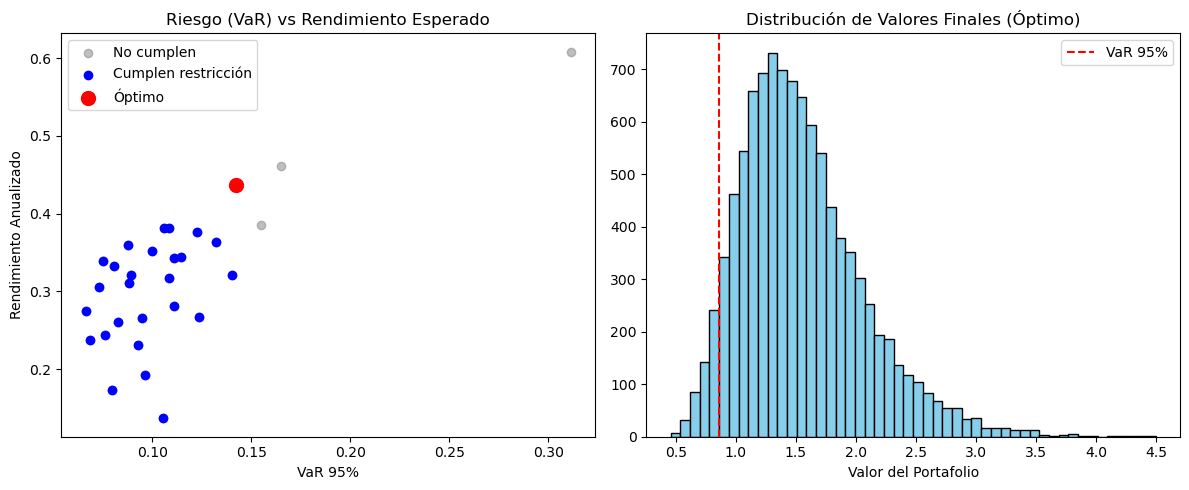

--- RESULTADOS ---
1. Portafolios que cumplen la restricción: 27 de 30
2. Rendimiento esperado del óptimo: 43.72%
3. Rendimiento sacrificado por controlar riesgo: 17.12%


In [70]:

k = len(stocks)
num_sim = 10000
n_combinations = 30 
limite_var = 0.15

L = np.linalg.cholesky(cov_matrix)

results = []

# 2. Bucle de Portafolios Aleatorios
for i in range(n_combinations):
    weights = np.random.rand(k)
    weights /= np.sum(weights)
    
    # Simulación MGB simplificada para velocidad
    # Rendimiento esperado anualizado del portafolio
    rend_esperado = (np.dot(weights, mean_returns) * 252) 
    
    portfolio_paths = np.zeros(num_sim)
    for m in range(num_sim):
        Z = np.random.normal(size=(252, k))
        daily_ret = (Z @ L.T + mean_returns.values) @ weights
        portfolio_paths[m] = np.prod(1 + daily_ret)
    
    var_95 = 1 - np.percentile(portfolio_paths, 5)
    
    results.append({
        "Pesos": weights,
        "Rendimiento": rend_esperado,
        "VaR": var_95,
        "Final_Paths": portfolio_paths # Guardamos para el histograma
    })

df = pd.DataFrame(results)

# 3. Identificar portafolios que cumplen la restricción
df_cumplen = df[df['VaR'] <= limite_var]
portafolio_optimo = df_cumplen.loc[df_cumplen['Rendimiento'].idxmax()] if not df_cumplen.empty else None

# 4. Visualización
plt.figure(figsize=(12, 5))

# Scatter Plot: Riesgo vs Rendimiento
plt.subplot(1, 2, 1)
plt.scatter(df['VaR'], df['Rendimiento'], c='gray', alpha=0.5, label='No cumplen')
plt.scatter(df_cumplen['VaR'], df_cumplen['Rendimiento'], c='blue', label='Cumplen restricción')
if portafolio_optimo is not None:
    plt.scatter(portafolio_optimo['VaR'], portafolio_optimo['Rendimiento'], c='red', s=100, label='Óptimo')
plt.title("Riesgo (VaR) vs Rendimiento Esperado")
plt.xlabel("VaR 95%")
plt.ylabel("Rendimiento Anualizado")
plt.legend()

# Histograma del Portafolio Elegido
plt.subplot(1, 2, 2)
if portafolio_optimo is not None:
    plt.hist(portafolio_optimo['Final_Paths'], bins=50, color='skyblue', edgecolor='black')
    plt.axvline(1 - portafolio_optimo['VaR'], color='red', linestyle='--', label='VaR 95%')
    plt.title("Distribución de Valores Finales (Óptimo)")
    plt.xlabel("Valor del Portafolio")
plt.legend()

plt.tight_layout()
plt.show()

# 5. Respuestas
max_rend_total = df['Rendimiento'].max()
sacrificio = max_rend_total - portafolio_optimo['Rendimiento']

print(f"--- RESULTADOS ---")
print(f"1. Portafolios que cumplen la restricción: {len(df_cumplen)} de {n_combinations}")
print(f"2. Rendimiento esperado del óptimo: {portafolio_optimo['Rendimiento']:.2%}")
print(f"3. Rendimiento sacrificado por controlar riesgo: {sacrificio:.2%}")